In [1]:
import numpy as np
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors


In [2]:
df = pd.read_csv(r"C:\Users\sampl\OneDrive\Desktop\Data-Analysis-Project\Loan\Loan-Data-Analysis\loan-approval-clean.csv")
analytics_df=df.copy()

#Data was processed in PostgresSQL, but to do a double take, we'll do a little additional processing

analytics_df[ "incomeValid" ] = analytics_df["Income"].where(analytics_df["Income"]>0)
analytics_df[ "loanAmountValid" ] = analytics_df["LoanAmount"].where(analytics_df["LoanAmount"]>0)
analytics_df[ "debtBurden" ] = analytics_df["loanAmountValid"] / analytics_df["incomeValid"]
analytics_df[ "debtBurdenClipped" ] = analytics_df[ "debtBurden" ].clip(upper=analytics_df["debtBurden"].quantile(0.99)) #Clipped the debt burden frame since there are some very far outliers

In [3]:
moneyFormat= mtick.StrMethodFormatter("${x:,.0f}") #formatting tools we can pass throughout the project
pctFormat = mtick.PercentFormatter(1.0)

#dictionary that allows us to carry information like labels and formatting
plotSpecs = [
    ("Age","Age", None),
    ("Income", "Income", moneyFormat),
    ("LoanAmount", "Loan Amount", moneyFormat),
    ("CreditScore", "Credit Score", None),
    ("YearsExperience", "Years of Experience", None),
    ("debtBurdenClipped", "Debt Burden", pctFormat)
]

#dictionary of colors
colorList = {
    "approval": '#00A878',
    "reject": '#cc1010',
    "accent": '#33658A',
    "ink": '#102542',
    "grid": '#D9E2EC',
    "gold": "#F4B942",
    "background": '#F7FAFC',
    "offwhite": '#FFF7E8'
    
}

sns.set_theme(style="whitegrid", context="talk")

#changing baseline plotting parameters 
plt.rcParams.update(
    {
        "figure.facecolor": colorList["background"],
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": colorList["ink"],
        "axes.labelcolor": colorList["ink"],
        "axes.titlecolor": colorList["ink"],
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.spines.top": True,
        "axes.spines.right": True,
        "grid.color": colorList["grid"],
        "grid.linewidth": 0.8,
        "grid.alpha":0.4,
        "xtick.color": colorList["ink"],
        "ytick.color": colorList["ink"],
        "font.size": 12,
        "figure.titlesize": 12,

    }
)

## Income to Debt Burden
Debt burden is the ratio of income to debt. This is a common calculation used by lendors when evaluating loan candidates. 

Debt burden is figured with the total amount of debt from the candidate. For this project, we will only consider the loan amount as the total amount of debt.

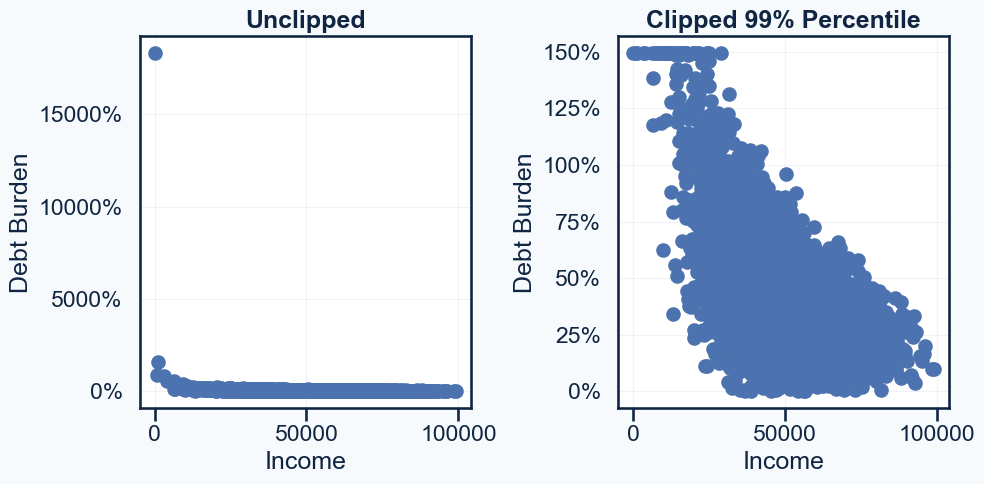

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

ax[0].scatter(analytics_df["Income"], analytics_df["debtBurden"])
ax[1].scatter(analytics_df["Income"], analytics_df["debtBurdenClipped"])
ax[0].set_title("Unclipped")
ax[1].set_title("Clipped 99% Percentile")
ax[0].set_ylabel("Debt Burden")
ax[1].set_ylabel("Debt Burden")
ax[0].set_xlabel("Income")
ax[1].set_xlabel("Income")

ax[0].yaxis.set_major_formatter(pctFormat)
ax[1].yaxis.set_major_formatter(pctFormat)

ax[0].xaxis.set_ticks_position('bottom')
ax[1].xaxis.set_ticks_position('bottom')


plt.tight_layout()
plt.savefig(
    'income-debtBurden.png',
    bbox_inches='tight'
)


## Data Spread

It's important to build an understanding of your data and the spread of your data. We'll build histograms in order to bin each loan approval factor and count.

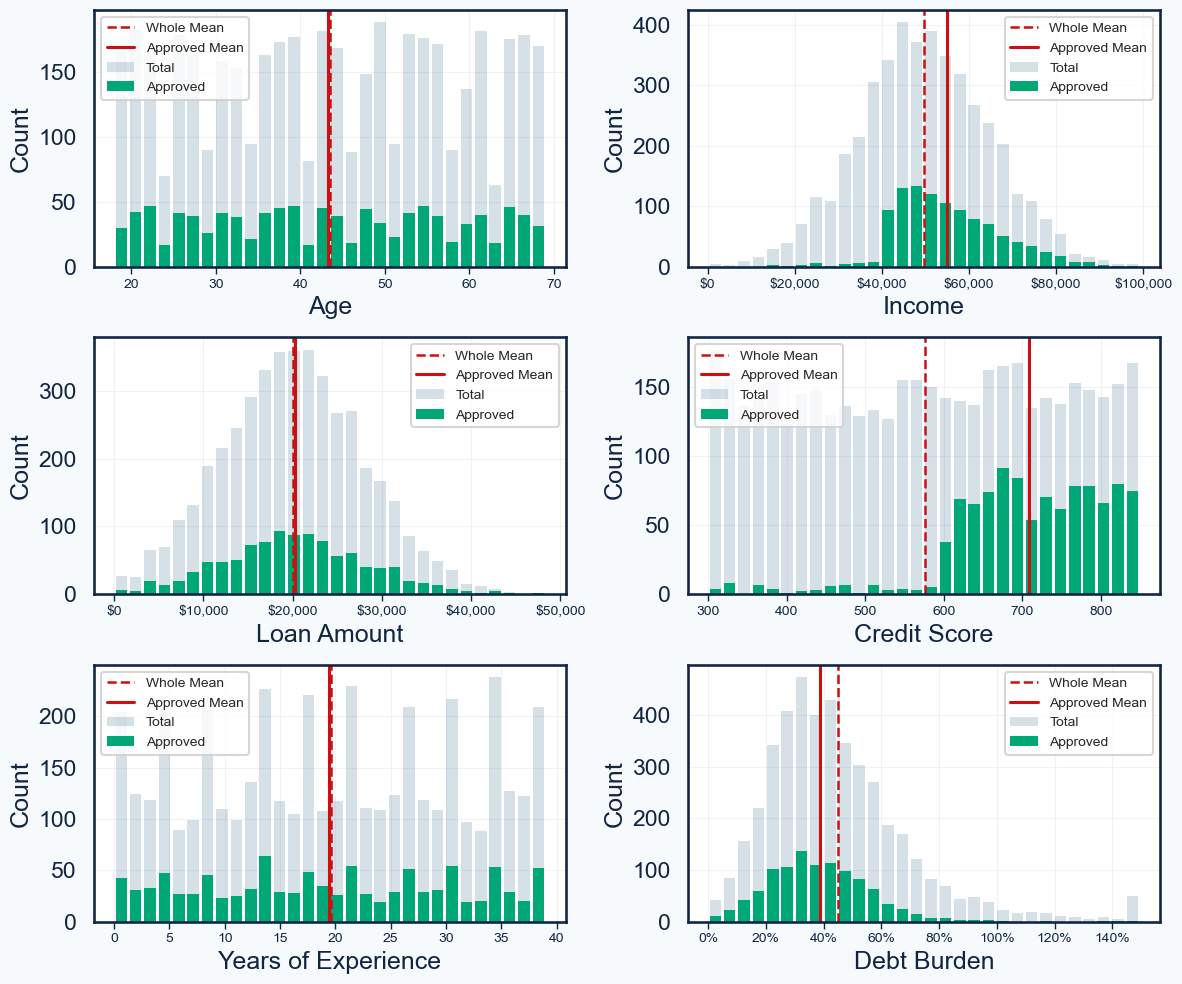

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(12,10))

for ax, (col, title, formatTool) in zip(axes.flat, plotSpecs):
    colSelection = analytics_df[[col,"LoanApproved"]]
    approvedSet = colSelection[colSelection["LoanApproved"]==1]

    sns.histplot(
        data=colSelection,
        x=col,
        bins=30,
        color=colorList["accent"],
        alpha=0.20,
        edgecolor="none",
        shrink=0.8,
        ax=ax,
        common_norm=True,
        label="Total"
        
    )

    sns.histplot(
        data=approvedSet,
        x=col,
        bins=30,
        binrange=(colSelection[col].min(), colSelection[col].max()),
        color=colorList["approval"],
        alpha=1,
        edgecolor="none",
        shrink=0.8,
        common_norm=True,
        ax=ax,
        label="Approved"
        
    )

    ax.axvline(colSelection[col].mean(), color=colorList["reject"], linestyle="--", linewidth=1.8, label="Whole Mean")
    ax.axvline(approvedSet[col].mean(), color=colorList["reject"], linewidth=2.2, label="Approved Mean")
    ax.legend(fontsize='small')

    if formatTool is not None:
        ax.xaxis.set_major_formatter(formatTool)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='x', which = 'major', length = 5, width = 1)
   
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlabel(title)

plt.tight_layout()
    
plt.savefig(
    fname='demographicInfo.png'
)



## Credit Score against Income 

It's expected that credit score and income have some correlation. Let's verify with a scatter plot. 

Additionally, we'll cut the plot into quadrants bound by high/low income & high/low credit score. A 'good' credit score for loan approval is considered to be 650, so we'll use that as our divider on the credit score axis. For the income axis divider, we'll use the mean of the income for the dataset.

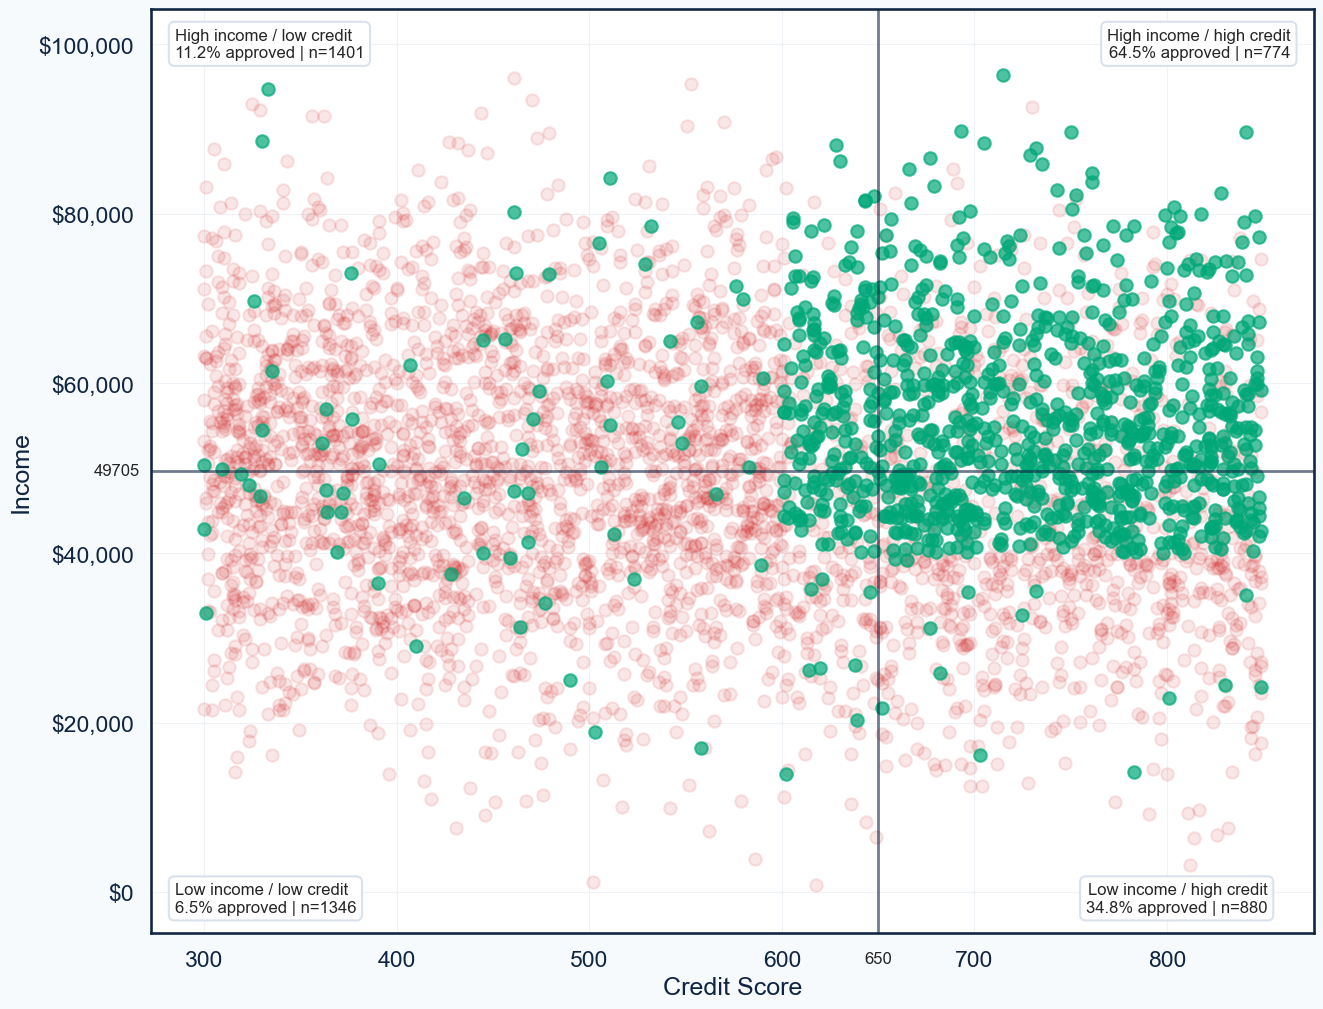

In [6]:
scatter_df = analytics_df[["incomeValid", "CreditScore", "LoanApproved"]].copy()
rej_df = scatter_df[scatter_df["LoanApproved"] == 0]
app_df = scatter_df[scatter_df["LoanApproved"] == 1]

incomeMed = scatter_df["incomeValid"].mean().round(decimals=0)
creditGood = 650

scatter_df["Quadrant"] = np.select(
    [
        (scatter_df["incomeValid"] < incomeMed) & (scatter_df["CreditScore"] < creditGood),
        (scatter_df["incomeValid"] < incomeMed) & (scatter_df["CreditScore"] >= creditGood),
        (scatter_df["incomeValid"] > incomeMed) & (scatter_df["CreditScore"] < creditGood),
        (scatter_df["incomeValid"] > incomeMed) & (scatter_df["CreditScore"] >= creditGood)
    ],
    [
        "Low income / low credit",
        "Low income / high credit",
        "High income / low credit",
        "High income / high credit"
    ],
    default="Unclassified"

)


scatterLabelPos = {
    "Low income / low credit": (0.02, 0.02, 'bottom', 'left'),
    "Low income / high credit": (0.96, 0.02, 'bottom', 'right'),
    "High income / low credit": (0.02, 0.98, 'top', 'left'),
   "High income / high credit": (0.98, 0.98, 'top', 'right'),
}

quadStats = scatter_df.groupby("Quadrant")["LoanApproved"].agg(rate="mean", count="size").copy()

fig, ax = plt.subplots(figsize=(15,12))

ax.scatter(

    rej_df["CreditScore"],
    rej_df["incomeValid"],
    color = colorList['reject'],
    alpha=0.1
)

ax.scatter(

    app_df["CreditScore"],
    app_df["incomeValid"],
    color = colorList['approval'],
    alpha=0.7
)

ax.axhline(incomeMed, color=colorList['ink'], linewidth = 2, alpha=0.6)
ax.axvline(creditGood, color=colorList['ink'], linewidth = 2, alpha=0.6)

for label, (xPos, yPos, vertA, horzA) in scatterLabelPos.items():
    selectedQuad = quadStats.loc[label]
    
    ax.text(
        xPos,
        yPos,
        f"{label}\n{selectedQuad['rate']:.1%} approved | n={int(selectedQuad['count'])}",
        transform=ax.transAxes,
        ha=horzA,
        va=vertA,
        bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": colorList["grid"],
                "alpha": 1,
            },
    )

ax.text(
    -0.01,
    incomeMed,
    f"{int(incomeMed)}",
    va = 'center',
    ha = 'right',
    transform=ax.get_yaxis_transform()
)

ax.text(
    creditGood,
    -.02,
    f"{int(creditGood)}",
    va = 'top',
    ha = 'center',
    transform=ax.get_xaxis_transform()
)

ax.set_xlabel("Credit Score")
ax.set_ylabel("Income")
ax.yaxis.set_major_formatter(moneyFormat)

plt.savefig(
    fname='credit-income.png'
)


## Bias and Relations Check

We need to check for demographic bias in the data. We will visualize each demographic. These plots only show approval for each demographic. We'll also get an idea of another loan approval factor like employment.

For this dataset, it appears the approval rate should be approx 24%. We've set that as the standard in each bias plot. Any variable within 1% is within range. Outside of that range, we should investigate.

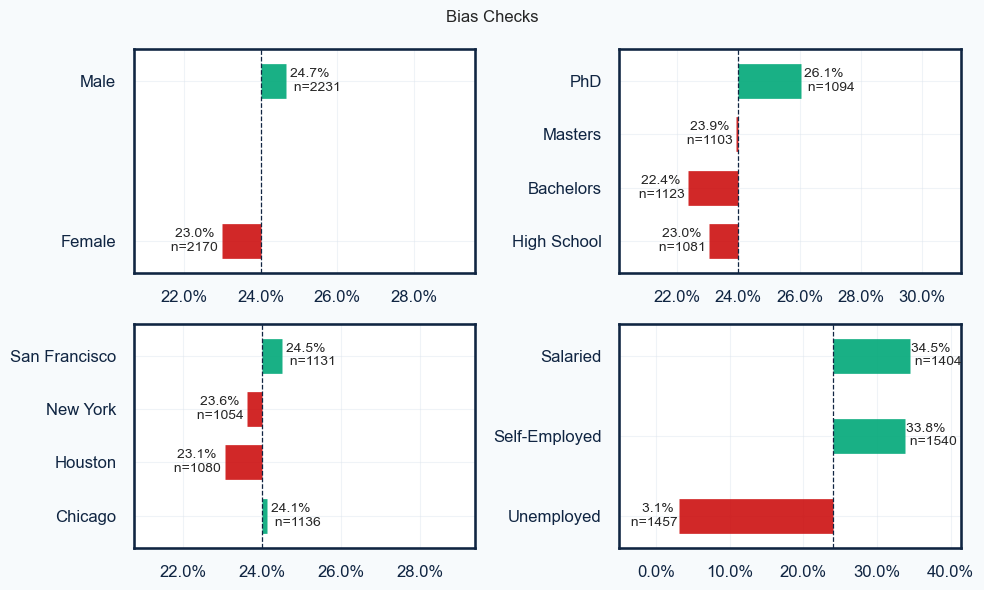

In [7]:
biasSpecs = [
    ("Gender", "Gender", ["Female", "Male"]),
    ("Education", "Education", ["High School", "Bachelors", "Masters", "PhD", "Missing"]),
    ("City", "City", ["Chicago", "Houston", "New York", "San Francisco"]),
    ("EmploymentType", "Employment Type", ["Unemployed", "Self-Employed", "Salaried"]),
]

fig, axes = plt.subplots( 2, 2, figsize=(10,6))

fig.suptitle('Bias Checks')

for ax, (col, title, order) in zip(axes.flat, biasSpecs):
    temp = analytics_df[[col,"LoanApproved"]]
    temp = (
        temp.groupby(col, dropna=False)["LoanApproved"]
        .agg(rate="mean", count="size")
        .reset_index()
    )

    if order is not None:
        temp[col] = pd.Categorical(temp[col], categories = order, ordered = True)
        temp = temp.sort_values(col)
    else:
        temp = temp.sort_values('rate')

    yVal = np.linspace(start=0, stop=1, num=len(temp))
    
    baseline_df = analytics_df[[col,'LoanApproved']]          
    
    baseline = .24

    colorSel = np.where(
        temp['rate'] >= baseline,
        colorList['approval'],
        colorList['reject']
    )
    ax.hlines(yVal, baseline, temp["rate"], linewidth=25, alpha=0.9, color=colorSel)

    min_rate = temp['rate'].min()

    if min_rate < 0.05:   # "close to 0" threshold (adjust if needed)
        xminVal = -0.05  # small negative buffer for visual space
    else:
        xminVal = min_rate * 0.9
    
    ax.set_xlim(xminVal, temp['rate'].max()*1.2)
    ax.xaxis.set_major_formatter(pctFormat)
    ax.tick_params(axis='x', labelsize=12)
    
    ax.set_yticks(yVal, temp[col].astype(str))
    ax.set_ylim(yVal.min()-0.2, yVal.max() + 0.2)
    ax.tick_params(axis='y', labelsize=12)
    
    ax.axvline(baseline,linestyle='--', color=colorList['ink'], linewidth=0.9)
    
    for y, (_, row) in zip(yVal, temp.iterrows()):

        horzAlign = "left" if row["rate"] >= baseline else "right"
        xTextPos = 0.001 if row["rate"] >= baseline else -.001
        ax.text(
            row["rate"] + xTextPos,              # x position (slightly right of line)
            y,                               # y position
            f"{row['rate']:.1%} \n n={int(row['count'])}",  # label
            va="center",
            ha=horzAlign,
            fontsize=10
        )

plt.tight_layout()

plt.savefig(
    fname='biasPlots.png'
)
plt.show()



### Bias Discussion

 We see that in the education plot, bachelor's level education is out of our 1% range. It is 0.6% out of range, but we will investigate. 
 
 Looking at the employment plot, we see a hefty skew with unemployed. We would expect a lower income with being in the unemployed set. We will investigate.

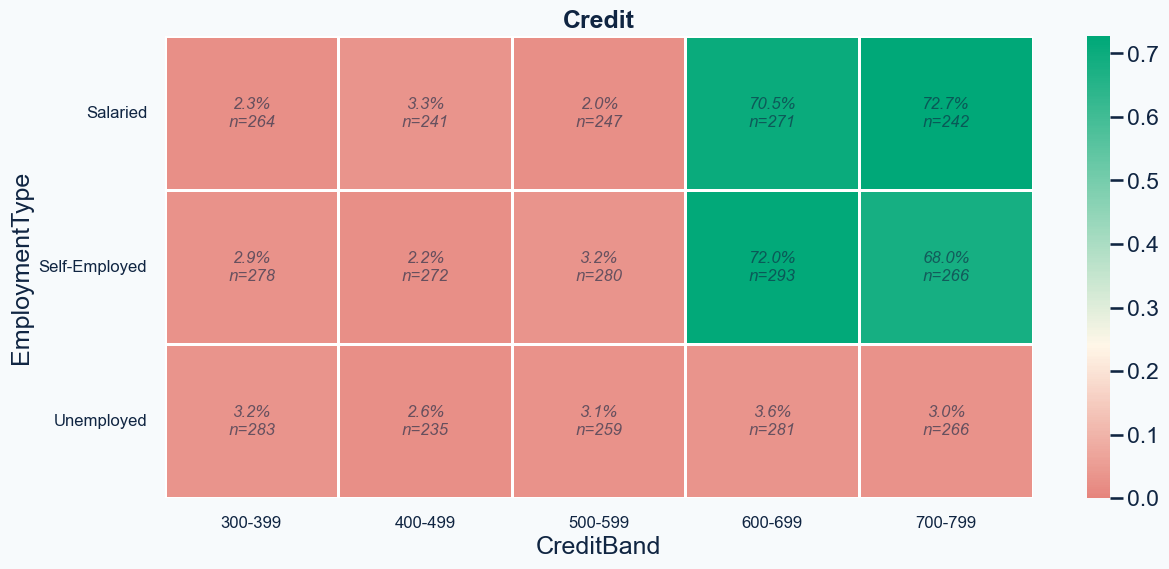

In [8]:
analytics_df['CreditBand'] = pd.cut(
    analytics_df['CreditScore'],
    bins=[300, 400, 500, 600, 700, 800 ],
    labels=["300-399", "400-499", "500-599", "600-699", "700-799"],
    include_lowest=True,
    right=False,
)

mean_df = analytics_df.groupby(['EmploymentType','CreditBand'], observed=True)['LoanApproved'].mean().unstack()
count_df = analytics_df.groupby(['EmploymentType','CreditBand'], observed=True)['LoanApproved'].count().unstack()

colorMap = mcolors.LinearSegmentedColormap.from_list(
    "approval_surface",
    [colorList['reject'], colorList['offwhite'], colorList['approval']]
    )

fig, ax = plt.subplots(figsize=(14,6))

heatLabels = pd.DataFrame()

for i in range(mean_df.shape[0]):
    for j in range (count_df.shape[1]):
        rate = mean_df.iloc[i, j]
        count = count_df.iloc[i, j]
        heatLabels.at[i, j] = f"{rate:.1%}\nn={int(count)}"

annotParams = {
    'fontsize': 12, 
    'fontstyle': 'italic', 
    'color':colorList['ink'], 
    'alpha': 0.6
    }


colorBarStyle = {
    'edgecolor' : colorList['ink'],
    "linewidth": 1.0
}

sns.heatmap(
    mean_df,
    cmap = colorMap,
    center = 0.24,
    vmin = 0,
    annot = heatLabels,
    fmt = '',
    ax=ax,
    annot_kws = annotParams,
    linewidths=1,                    
    linecolor='white',
    )

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, va='top')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')

ax.set_title("Credit")

plt.savefig(
    fname='credit-employment.png'
)



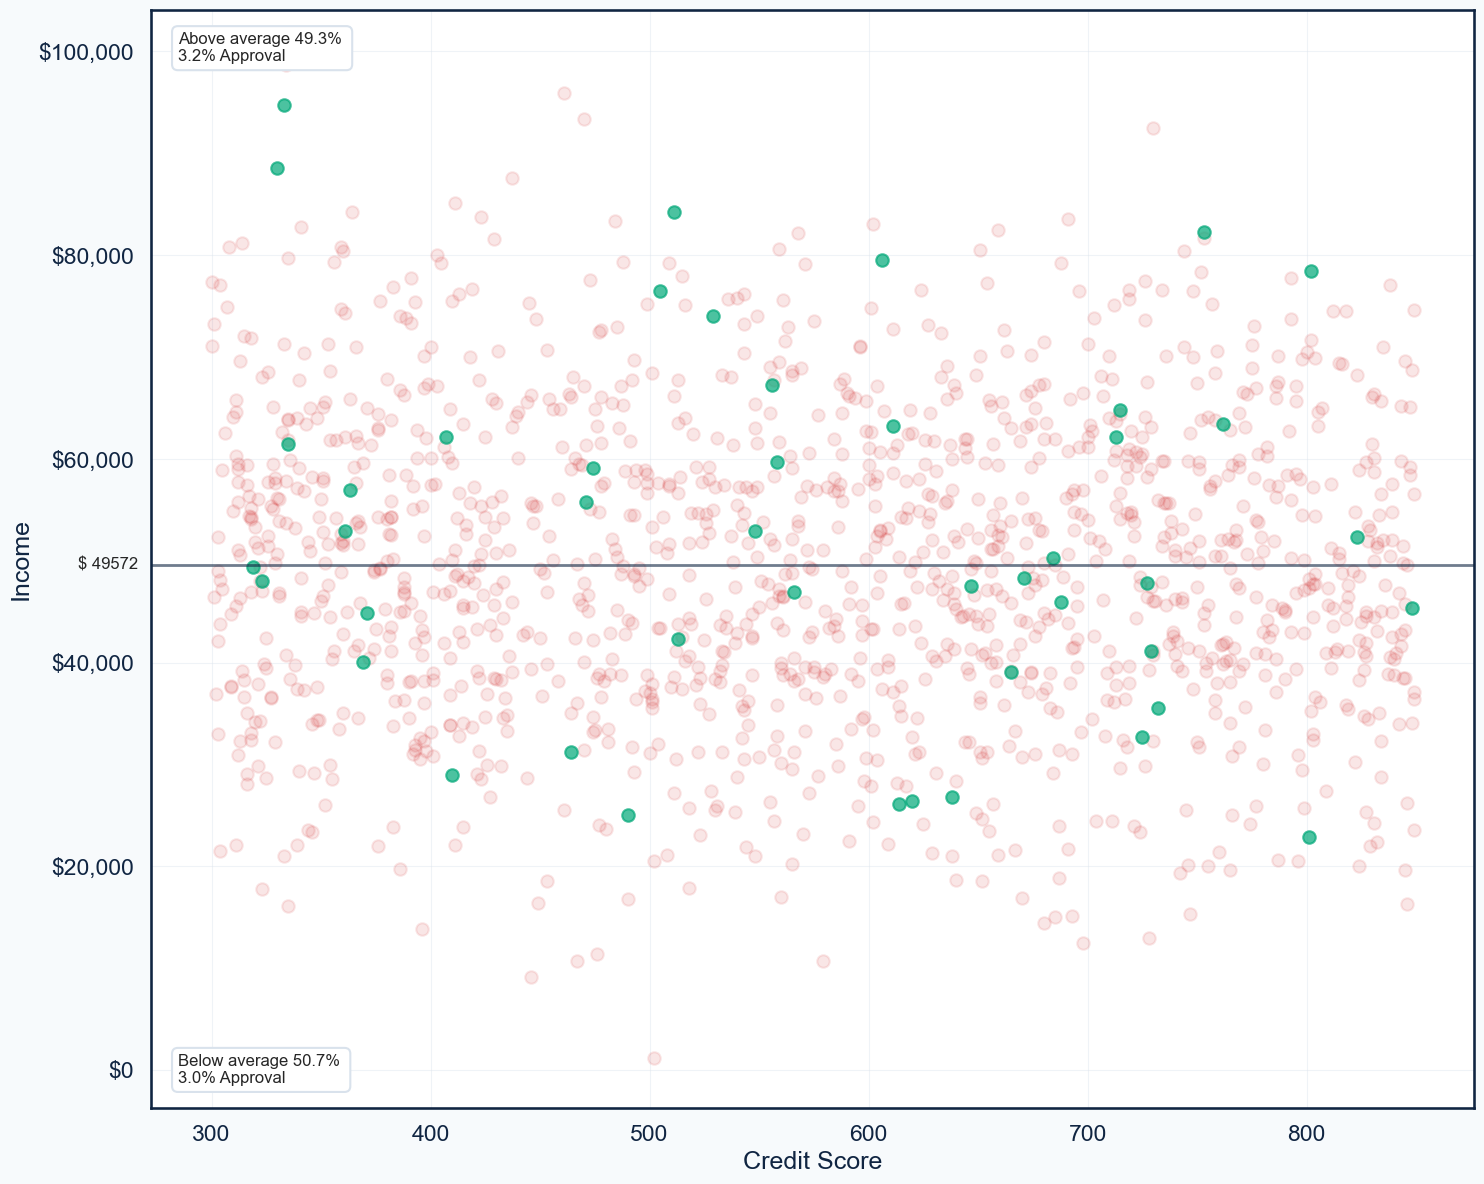

In [9]:
scatter_df = analytics_df[["incomeValid", "CreditScore", "LoanApproved", "EmploymentType"]]
scatter_df = scatter_df[scatter_df["EmploymentType"] == 'Unemployed'].copy()

scatter_df["Split"] = np.select(
    [
        (scatter_df["incomeValid"] < incomeMed),
        (scatter_df["incomeValid"] >= incomeMed)
    ],
    [
        "Below average",
        "Above average",

    ],
    default="Unclassified"

)


rej_df = scatter_df[scatter_df["LoanApproved"] == 0]
app_df = scatter_df[scatter_df["LoanApproved"] == 1]

incomeMed = scatter_df["incomeValid"].mean().round(decimals=0)
creditGood = 650


scatterLabelPos = {
    "Below average": (0.02, 0.02, 'bottom', 'left'),
    "Above average": (0.02, 0.98, 'top', 'left')
}

splitStats = scatter_df.groupby("Split").agg(
    count=("Split", "size"), rate=('LoanApproved', 'mean')
)

splitStats["pct"] = splitStats["count"] / splitStats["count"].sum()

approvalRates = scatter_df.groupby("Split")["LoanApproved"].agg(rate='mean').copy()

fig, ax = plt.subplots(figsize=(15,12))

ax.scatter(

    rej_df["CreditScore"],
    rej_df["incomeValid"],
    color = colorList['reject'],
    alpha=0.1
)

ax.scatter(

    app_df["CreditScore"],
    app_df["incomeValid"],
    color = colorList['approval'],
    alpha=0.7
)

ax.axhline(incomeMed, color=colorList['ink'], linewidth = 2, alpha=0.6)

for label, (xPos, yPos, vertA, horzA) in scatterLabelPos.items():
    selectedHalf = splitStats.loc[label]
    selectedApproval = approvalRates.loc[label]
    
    ax.text(
        xPos,
        yPos,
        f"{label} {selectedHalf['pct']:.1%} \n{selectedApproval['rate']:.1%} Approval",
        transform=ax.transAxes,
        ha=horzA,
        va=vertA,
        bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": colorList["grid"],
                "alpha": 1,
            },
    )

ax.text(
    -0.01,
    incomeMed,
    f"$ {int(incomeMed)}",
    va = 'center',
    ha = 'right',
    transform=ax.get_yaxis_transform()
)


ax.set_xlabel("Credit Score")
ax.set_ylabel("Income")
ax.yaxis.set_major_formatter(moneyFormat)
plt.tight_layout()
plt.savefig(
    'credit-incomeEmployment.png',
    bbox_inches='tight'
)


## Employment Discussion

Looking at income against credit score in different forms, there doesn't seem to be any correlation that would directly correlate with the unemployed having a low approval rate. Incomes amongst the unemployed are roughly split above and below the average income for the data set. In those 2 groups, the approval rate is approximately the same.

It would be reasonable to assume that lenders would not risk approving a loan for an individual without proof of steady income from an employer. We would need additional data to verify that claim.

## Correlation

To confirm that credit score and income are the largest factors that lenders look at, we'll create a Pearson Correlation Coeff matrix. Higher positive values signifies stronger positive correlation. Negative values signifies a stronger negative correlation.

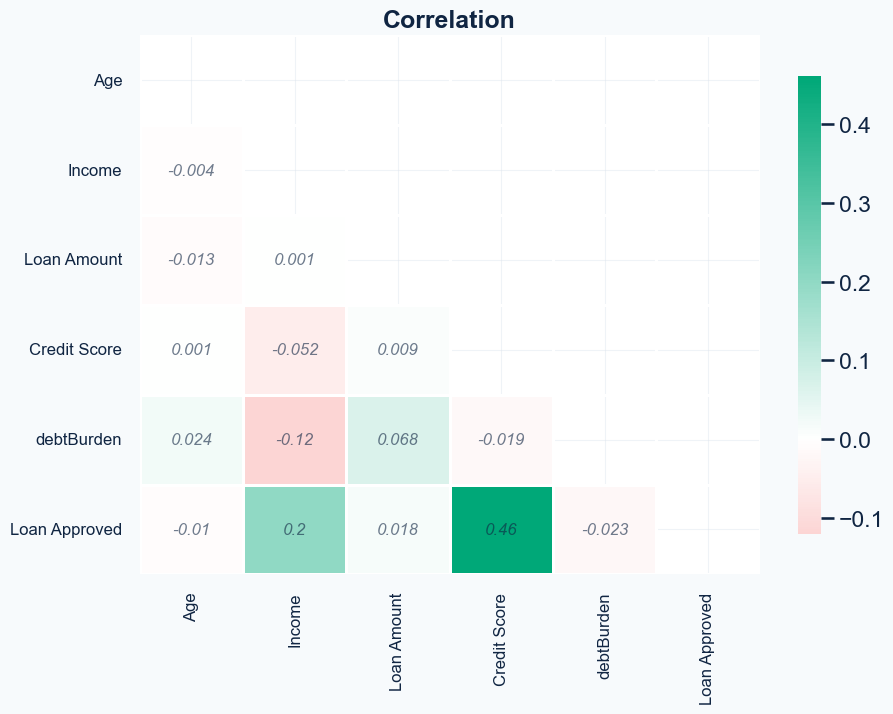

In [10]:
corrCol = ['Age', 
           'incomeValid', 
           'loanAmountValid', 
           'CreditScore', 
           'debtBurden', 
           'LoanApproved'
          ]

labelMap = {
    'Age': 'Age',
    'incomeValid': 'Income',
    'loanAmountValid': 'Loan Amount',
    'CreditScore': 'Credit Score',
    'debtBurdeClipped': 'Debt Burden Ratio',
    'LoanApproved': 'Loan Approved'
}



corr = analytics_df[corrCol].corr(numeric_only=True).round(decimals = 3)
labelsRenamed = corr.rename(index=labelMap, columns=labelMap)

corr_cmap=mcolors.LinearSegmentedColormap.from_list("corr_map", ["#F25F5C", "#FFFFFF", "#00A878"])
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10,7))

sns.heatmap(
    labelsRenamed, 
    cmap = corr_cmap,
    center = 0,
    mask = mask,
    annot = True,
    linewidths=1,
    linecolor="white",
    annot_kws = annotParams,
    cbar_kws={"shrink": 0.85 }
)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, va='top')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')

ax.set_title("Correlation")


plt.savefig(
    'correlation.png',
    bbox_inches='tight'
)

## Final Discussion

From the correlation matrix, it's safe to say that credit score and income are the largest driving factors for loan approval.

This dataset could be used for machine learning to predict if a loan application will be approved.

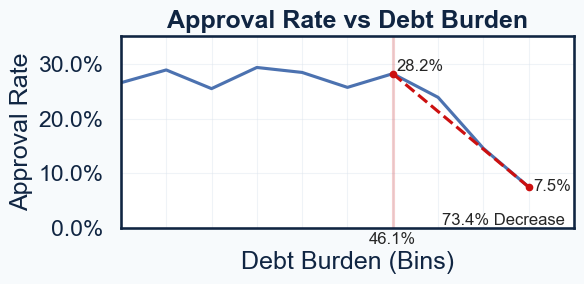

In [11]:
debtBurden_df = analytics_df[['debtBurdenClipped', 'LoanApproved']].copy()

debtBurden_df['debtBurdenBin'] = pd.qcut(debtBurden_df['debtBurdenClipped'], q=10)

debtBurdenPlot = debtBurden_df.groupby('debtBurdenBin', observed=True)['LoanApproved'].mean().reset_index()
        
fig, ax = plt.subplots(figsize=(6,3))

ax.plot(
    debtBurdenPlot['debtBurdenBin'].astype(str),
    debtBurdenPlot['LoanApproved'],
)

ax.set_xlabel("Debt Burden (Bins)")
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate vs Debt Burden")

ax.tick_params(axis='x', rotation=30)
ax.set_xticklabels([])

ax.yaxis.set_major_formatter(pctFormat)

vLineVal = 6

debtBurdenPlot['binLabel'] = debtBurdenPlot['debtBurdenBin'].apply(
    lambda x: f"{x.left:.1%}"
)

vLineValLabel = debtBurdenPlot['binLabel'].iloc[vLineVal]

ax.text(
    vLineVal,
    -0.02,
    f"{vLineValLabel}",
    transform=ax.get_xaxis_transform(),
    va='top',
    ha='center'
)

beforeDeclineRate = debtBurdenPlot['LoanApproved'].iloc[vLineVal]

lastRateIDX = len(debtBurdenPlot) - 1
lastRate = debtBurdenPlot['LoanApproved'].iloc[lastRateIDX]

ax.text(
    vLineVal+0.6,
    beforeDeclineRate,
    f"{beforeDeclineRate:.1%}",
    ha='center',
    va='bottom'
)

ax.text(
    lastRateIDX+0.1,
    lastRate,
    f"{lastRate:.1%}",
    ha='left',
    va='center'
)

ax.plot(
    [vLineVal, lastRateIDX],
    [beforeDeclineRate, lastRate],
    linestyle='--',
    marker='.',
    color=colorList['reject']
)

ax.axvline(
    vLineVal,
    color = colorList['reject'],
    alpha = 0.2
)

ax.set_xlim(0, len(debtBurdenPlot))
ax.set_ylim(0, .35)

calc_df = pd.DataFrame(
    [beforeDeclineRate, lastRate],
    [vLineVal, lastRateIDX],

)

percentDiff = calc_df.pct_change()

percentDiffPull = abs(percentDiff.iloc[-1, 0])

ax.text(
    len(debtBurdenPlot)-0.2,
    0,
    f"{percentDiffPull:.1%} Decrease",
    ha='right',
    va='bottom'
)

plt.tight_layout()
plt.savefig(
    'debtBurdenApprovalRate.png',
    bbox_inches='tight'
)
plt.show()